## Step 1: Panel data preparation (Date–Country)

- The raw `features_raw` file is in **long format**: each row is one `(Date, Country)` observation (for example `1985-01-01 / Brazil / features...`, later `1985-01-01 / Philippines / features...`).

- We **do not merge** different countries with the same date into a single row; instead, each country–date pair is its own training sample.

- We set `Date` as the index (while keeping `Country` as a column), drop the crisis label columns and `Country` from the feature set, and use all remaining numeric columns as features.

- This lets the models learn on a stacked panel of all countries over time, while we still control which countries go into training, validation, and the held-out backtest (Philippines) using the `Country` column and the time-based CV plan.

In [8]:
FEATURES = [
    'real_interest_rate',          # keep (drop interest_differential)
    'fx_depreciation_mom',
    'reserves_change_mom', 'reserves_change_yoy',
    'reserve_adequacy_months', 'm2_reserves_ratio',
    'inflation_accel_3m', 'Inflation_YoY_%',
    'capital_flow_pct',            # keep (drop trade_to_reserves)
    'export_growth_yoy', 'm2_growth_yoy', 'credit_boom_yoy',
    'reer_misalignment', 'std_vulnerability', 'reserves_to_std_proxy',
]

In [9]:
print(len(FEATURES))

15


In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import optuna

# ------------------------------------------------------------------
# Load features_raw panel data (long format)
# ------------------------------------------------------------------
data_path = "preprocess/features_raw.csv"
df = pd.read_csv(data_path, parse_dates=["Date"])

target_col = "crisis_in_6m"
backtest_country = "Philippines"

# Keep rows with a defined target
df = df[~df[target_col].isna()].copy()

# Sort by date and country to keep correct time order
df = df.sort_values(["Date", "Country"]).reset_index(drop=True)

# Set Date as index but keep Country as a column
df.set_index("Date", inplace=True)

# Fill missing values with 0 (features and other numeric columns)
df = df.fillna(0)

# Features are taken from the pre-defined FEATURES list
X = df[FEATURES].copy()
y = df[target_col].astype(int)

# Split out Philippines as strict backtest set
mask_backtest = df["Country"] == backtest_country

X_train_full = X[~mask_backtest].copy()
y_train_full = y[~mask_backtest].copy()
X_backtest = X[mask_backtest].copy()
y_backtest = y[mask_backtest].copy()

print("Training samples (non-Philippines):", X_train_full.shape[0])
print("Backtest samples (Philippines):", X_backtest.shape[0])
print("Positive rate in training set (crisis in 6m):", y_train_full.mean())

Training samples (non-Philippines): 12672
Backtest samples (Philippines): 623
Positive rate in training set (crisis in 6m): 0.140625


In [ ]:
# ------------------------------------------------------------------
# Time-ordered train/validation split for Optuna hyperparameter search
# ------------------------------------------------------------------
# Ensure non-Philippines training data are sorted by date (index)
X_train_full_sorted = X_train_full.sort_index()
y_train_full_sorted = y_train_full.sort_index()

# Use a time-based split: earliest observations for training, latest for validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full_sorted, y_train_full_sorted,
    test_size=0.25,
    shuffle=False,  # keep chronological order
 )

print("Train size:", X_train.shape[0])
print("Valid size:", X_valid.shape[0])
print("Positive rate (train):", y_train.mean())
print("Positive rate (valid):", y_valid.mean())

# ------------------------------------------------------------------
# Optuna objective: maximize ROC-AUC on validation set
# ------------------------------------------------------------------
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 20, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "random_state": 42,
        "n_jobs": -1,
    }
    # enforce class weighting to address imbalance
    class_weight_1 = trial.suggest_float("class_weight_1", 1.0, 20.0)
    params["class_weight"] = {0: 1, 1: class_weight_1}
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    y_valid_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_proba)
    return auc

study = optuna.create_study(direction="maximize", study_name="rf_crisis_6m")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best AUC:", study.best_value)
print("Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-03-17 17:42:31,941] A new study created in memory with name: rf_crisis_6m


Train size: 9504
Valid size: 3168
Positive rate (train): 0.15561868686868688
Positive rate (valid): 0.09564393939393939


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-17 17:42:32,127] Trial 0 finished with value: 0.6043843127768274 and parameters: {'n_estimators': 41, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 'log2', 'class_weight_1': 19.215665019160845}. Best is trial 0 with value: 0.6043843127768274.
[I 2026-03-17 17:42:32,240] Trial 1 finished with value: 0.5706725646386628 and parameters: {'n_estimators': 20, 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'log2', 'class_weight_1': 16.729020773792037}. Best is trial 0 with value: 0.6043843127768274.
[I 2026-03-17 17:42:32,240] Trial 1 finished with value: 0.5706725646386628 and parameters: {'n_estimators': 20, 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'log2', 'class_weight_1': 16.729020773792037}. Best is trial 0 with value: 0.6043843127768274.
[I 2026-03-17 17:42:32,557] Trial 2 finished with value: 0.6051549657583559 and parameters: {'n_estimators': 94, 'max_depth': 18, 'min_sam

In [29]:
# ------------------------------------------------------------------
# Train final class-weighted RandomForest on all non-Philippines data
# and evaluate on the held-out Philippines backtest set
# ------------------------------------------------------------------

best_params = study.best_params.copy()

class_weight_1 = best_params.pop("class_weight_1")

best_params.update({
    "class_weight": {0: 1, 1: class_weight_1},
    "random_state": 42,
    "n_jobs": -1,
})

final_model = RandomForestClassifier(**best_params)
final_model.fit(X_train_full, y_train_full)

# Predictions on Philippines backtest set
y_backtest_proba = final_model.predict_proba(X_backtest)[:, 1]
y_backtest_pred = (y_backtest_proba >= 0.5).astype(int)

backtest_auc = roc_auc_score(y_backtest, y_backtest_proba)

print("Backtest (Philippines) ROC-AUC:", backtest_auc)
print("Backtest classification report (threshold = 0.5):")
print(classification_report(y_backtest, y_backtest_pred, digits=3))

print("Backtest confusion matrix:")
print(confusion_matrix(y_backtest, y_backtest_pred))

# Optional: inspect a small sample of predictions
backtest_results = X_backtest.copy()
backtest_results["y_true"] = y_backtest
backtest_results["y_proba"] = y_backtest_proba
backtest_results["y_pred"] = y_backtest_pred

Backtest (Philippines) ROC-AUC: 0.837513961280715
Backtest classification report (threshold = 0.5):
              precision    recall  f1-score   support

           0      0.938     0.776     0.849       544
           1      0.295     0.646     0.405        79

    accuracy                          0.759       623
   macro avg      0.616     0.711     0.627       623
weighted avg      0.856     0.759     0.793       623

Backtest confusion matrix:
[[422 122]
 [ 28  51]]


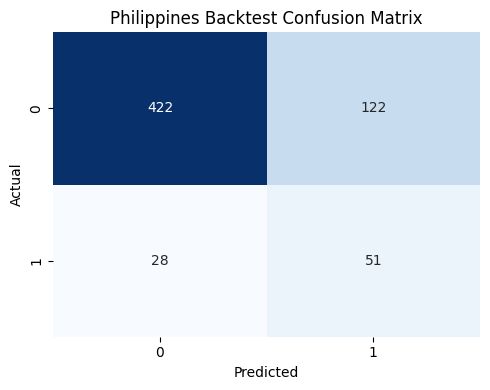

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------
# Plot confusion matrix for Philippines backtest
# ------------------------------------------------------------------
cm = confusion_matrix(y_backtest, y_backtest_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Philippines Backtest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("plots/confusion_matrix_philippines.png", dpi=150, bbox_inches="tight")
plt.show()

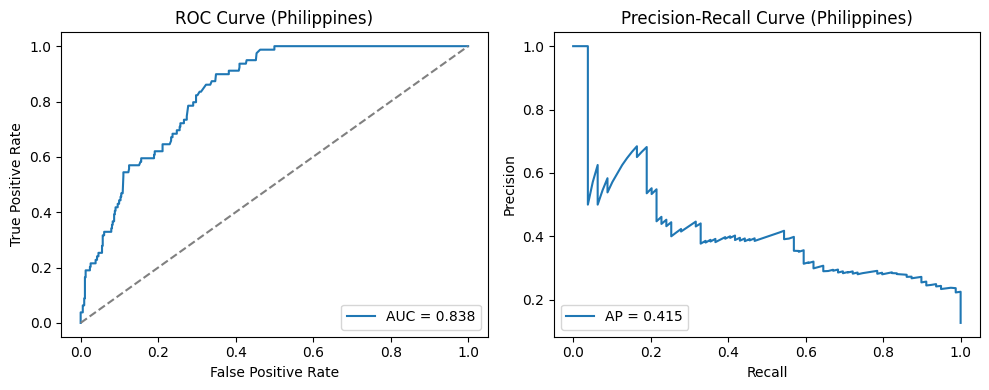

In [32]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ------------------------------------------------------------------
# ROC and Precision-Recall curves for Philippines backtest
# ------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_backtest, y_backtest_proba)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_backtest, y_backtest_proba)
pr_auc = average_precision_score(y_backtest, y_backtest_proba)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ROC curve
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve (Philippines)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

# Precision-Recall curve
axes[1].plot(recall, precision, label=f"AP = {pr_auc:.3f}")
axes[1].set_title("Precision-Recall Curve (Philippines)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.savefig("plots/roc_pr_curves_philippines.png", dpi=150, bbox_inches="tight")
plt.show()

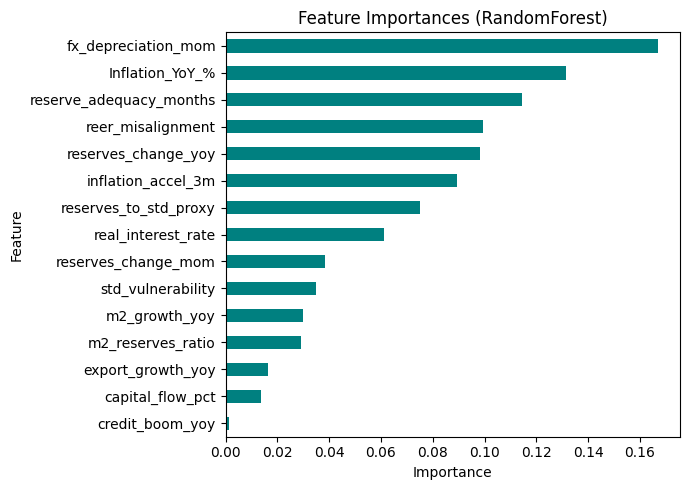

In [33]:
# ------------------------------------------------------------------
# Feature importance plot (trained final model)
# ------------------------------------------------------------------
importances = pd.Series(final_model.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(7, 5))
importances.plot(kind="barh", color="teal")
plt.title("Feature Importances (RandomForest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("plots/feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()